In [124]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Load spacecraft positions exported from JPL Horizons.
base_path = Path.cwd()
csv_path = base_path / "ephemeris_positions.csv"
print(f"Reading ephemeris from: {csv_path}")

df = pd.read_csv(csv_path)
df = df.rename(columns={"utc": "time", "x_km": "x", "y_km": "y", "z_km": "z"})

# Convert time to datetime (optional but handy)
df["time"] = pd.to_datetime(df["time"])

j2000_time = pd.to_datetime(["2000-01-01 12:00:00"])
j2000_epoch = j2000_time.to_julian_date()
df["abs_time"] = df["time"] - (df["time"][0] - j2000_time[0])


Reading ephemeris from: /home/pavel/build/flat-earth/artemis/ephemeris_positions.csv


In [125]:

# Earth Rotation Angle (ERA) relative to the inertial x-axis of the OEM frame.
# For an OEM in an Earth-centered inertial frame (e.g. EME2000/J2000-like),
# this gives the Earth's sidereal rotation phase at each epoch.



def era_iau2000_from_utc(times_utc):
    # Convert pandas datetimes to Julian Date (UTC approximation for UT1).
    # ERA formula (IAU 2000):
    # theta = 2*pi*(0.7790572732640 + 1.00273781191135448*(JD_UT1 - 2451545.0))
    jd = pd.DatetimeIndex(times_utc).to_julian_date().to_numpy()

    theta = 2.0 * np.pi * (
        0.7790572732640 + 1.00273781191135448 * (jd - 2451545.0)
    )
    return np.mod(theta, 2.0 * np.pi)


df["earth_rotation_angle"] = era_iau2000_from_utc(df["abs_time"])
df["earth_rotation_angle_deg"] = np.degrees(df["earth_rotation_angle"])



In [130]:
R = 6378
df['r'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
df['r_flat'] = R * np.log(df['r'] / R)
df['phi'] = np.arctan2(np.sqrt(df['x']**2 + df['y']**2), df['z'])
df['theta'] = np.arctan2(df['y'], df['x']) - df["earth_rotation_angle"]
df

,time,jdut,x,y,z,abs_time,earth_rotation_angle,earth_rotation_angle_deg,r,r_flat,phi,theta
0,2026-04-02 01:58:00,2.461133e+06,-24510.238269,-14465.592783,-1296.568727,2000-01-01 12:00:00,4.894961,280.460618,28490.107845,9545.967686,1.616321,-7.503382
1,2026-04-02 01:59:00,2.461133e+06,-24619.178638,-14697.018814,-1316.660982,2000-01-01 12:01:00,4.899336,280.711303,28702.611640,9593.363769,1.616685,-7.502737
2,2026-04-02 02:00:00,2.461133e+06,-24726.597048,-14927.536238,-1336.668397,2000-01-01 12:02:00,4.903712,280.961987,28914.055788,9640.176502,1.617042,-7.502166
3,2026-04-02 02:01:00,2.461133e+06,-24832.492150,-15157.145221,-1356.586777,2000-01-01 12:03:00,4.908087,281.212672,29124.423519,9686.412422,1.617392,-7.501666
4,2026-04-02 02:02:00,2.461133e+06,-24937.068539,-15385.904717,-1376.447667,2000-01-01 12:04:00,4.912462,281.463356,29333.906311,9732.123170,1.617737,-7.501237
...,...,...,...,...,...,...,...,...,...,...,...,...
7916,2026-04-07 13:54:00,2.461138e+06,-125688.153849,-366741.814461,-37786.559168,2000-01-06 23:56:00,1.830479,104.878748,389518.798707,26226.703113,1.667957,-3.731447
7917,2026-04-07 13:55:00,2.461138e+06,-125671.332609,-366713.308046,-37787.234144,2000-01-06 23:57:00,1.834855,105.129433,389486.596948,26226.175818,1.667967,-3.735805
7918,2026-04-07 13:56:00,2.461138e+06,-125654.503352,-366684.795703,-37787.907970,2000-01-06 23:58:00,1.839230,105.380117,389454.387061,26225.648346,1.667977,-3.740163
7919,2026-04-07 13:57:00,2.461138e+06,-125637.666089,-366656.277423,-37788.580647,2000-01-06 23:59:00,1.843605,105.630802,389422.169042,26225.120698,1.667987,-3.744521


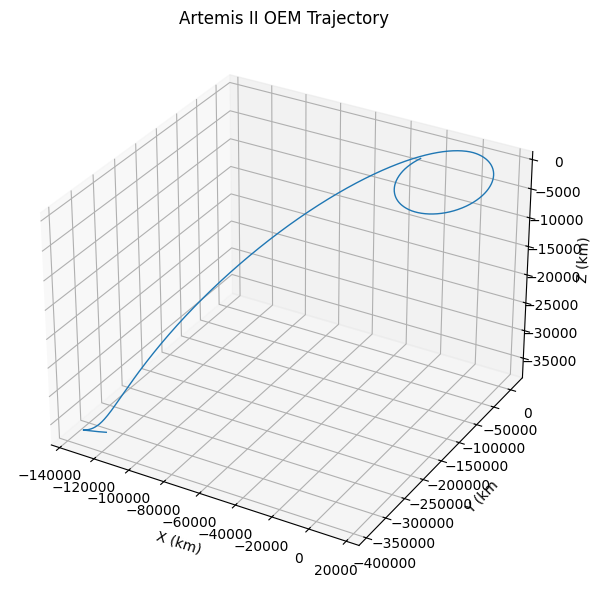

In [132]:
# Simple 3D trajectory plot of position
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(df["x"], df["y"], df["z"], linewidth=1)

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km")
ax.set_zlabel("Z (km)")
ax.set_title("Artemis II OEM Trajectory")

plt.tight_layout()
plt.show()

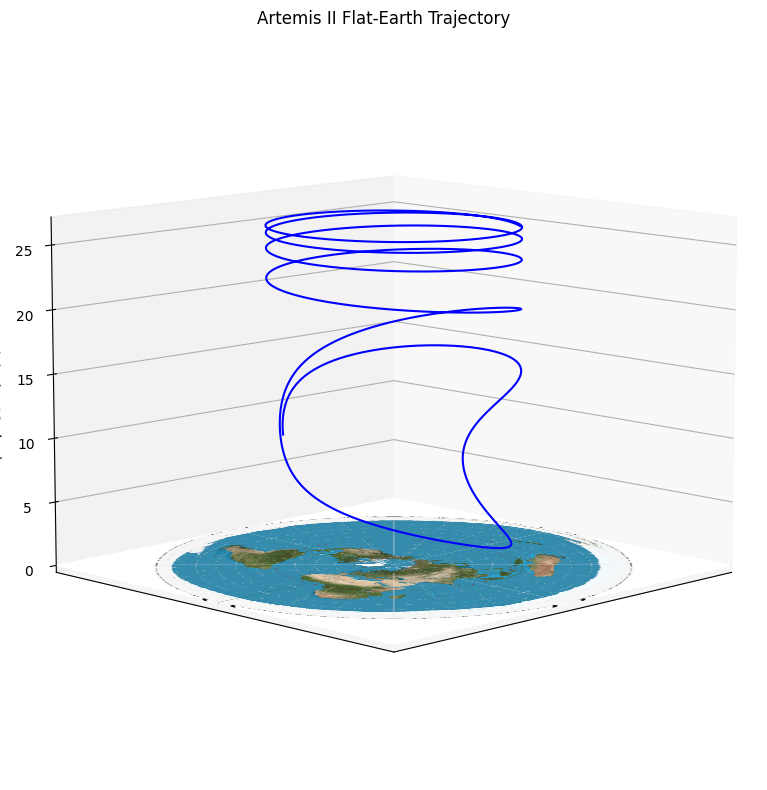

In [156]:
from matplotlib import cm

# 3D trajectory plot over flat earth
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)

# # Add Earth projection as an upward-facing XY plane at z=0.
img = plt.imread("../earth-projection.jpg")
w, h, _ = img.shape

plane_min, plane_max = -20000.0, 20000.0
x_range = np.arange(plane_min, plane_max, 100)
y_range = np.arange(plane_min, plane_max, 100)
x, y = np.meshgrid(x_range, y_range)
z = 0 * x
c = img[((x - plane_min) / (plane_max - plane_min) * w).astype(int), ((y - plane_min) / (plane_max - plane_min) * h).astype(int), :]
ax.plot_surface(
    x,
    y,
    z,
    rstride=1,
    cstride=1,
    facecolors=c/255.0,
    shade=False,
    zorder=1
)


# Flat-earth trajectory coordinates
x_flat = R * df["phi"] * np.cos(df["theta"])
y_flat = R * df["phi"] * np.sin(df["theta"])
ax.plot(x_flat, y_flat, df["r_flat"]/1000, color="blue", linewidth=1.5, zorder=2)

ax.set_xlim(plane_min, plane_max)
ax.set_ylim(plane_min, plane_max)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zlabel("Height (1000×km)")
ax.set_title("Artemis II Flat-Earth Trajectory")
ax.view_init(elev=10, azim=45, roll=0)

plt.tight_layout()
# plt.show()
plt.savefig("flat-earth-trajectory.png")